# Web Scraping : scraper plusieurs pages

---
## Imports

In [1]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Liste d'URLs à scraper
# on pars de la base de l'url d'acceuil
url = "https://www.chucknorrisfacts.fr/facts/"
# Définition d'une liste vide qui contiendra les urls
urls_to_scrape = list()
# Boucle pour capter les urls facts
for i in range(1,6):
    urls_to_scrape.append(f"{url}top/{i}")
# Affichage de la liste
urls_to_scrape

['https://www.chucknorrisfacts.fr/facts/top/1',
 'https://www.chucknorrisfacts.fr/facts/top/2',
 'https://www.chucknorrisfacts.fr/facts/top/3',
 'https://www.chucknorrisfacts.fr/facts/top/4',
 'https://www.chucknorrisfacts.fr/facts/top/5']

In [4]:
# Définition d'un dictionnaire vide qui contiendra le résulat des requêtes
mon_dictionnaire = dict()
# Fonction de récupération des résultats
def sortie(urls):
    # 1èere boucle pour tourner sur chaque url
    for url in urls:
        page = requests.get(url)
        soup = BeautifulSoup(page.content, 'html.parser')
        # 2ème boucle pour entrés les clés/valeurs dans le `mon_dictionnaire`
        for i in range(0, len(soup.find_all(class_="card-text"))):
            spans = soup.find_all('span', id=re.compile(r"moyenne_"))
            mon_dictionnaire[soup.find_all(class_="card-text")[i].text] = re.search(r"[\d.]+", spans[i].text).group()
    return mon_dictionnaire

In [5]:
# Création du DataFrame à partir de la sortie de la focntion `sortie`
# la commande n'acceptait pas le paramètre interne de changement de nom -> utilisation de la méthode .rename()
df = pd.DataFrame.from_dict(sortie(urls_to_scrape).items()).rename(columns={0:'Blagues', 1:'Notes'})
# Affichage du DataFrame
df

,Blagues,Notes
0,Les ennemis des amis de Chuck Norris sont ses ...,8.81
1,Chuck Norris peut manger plus de donuts qu'Homer.,8.80
2,"Un jour Chuck Norris a eu un zero en latin, de...",8.42
3,L'avenir se demande parfois ce que Chuck Norri...,8.41
4,Chuck Norris ne sait pas à quoi ressemble Nico...,8.40
...,...,...
94,Chuck Norris peut mettre un headshot au cavali...,8.21
95,"Aux Jeux Olympiques, Chuck Norris a été disqua...",8.21
96,Chuck Norris a réalisé un film avec Paint,8.21
97,"Dans un examen de maths, Chuck Norris a répond...",8.21


<Axes: xlabel='Count', ylabel='Notes'>

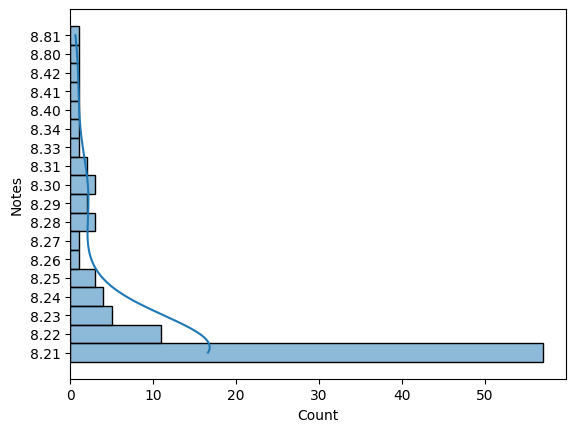

In [8]:
# Visualisation de la distribution des notes 
sns.histplot(data=df, y=df.Notes, kde=True)